In [2]:
import gc
import glob
from datetime import datetime
import torch
from transformers import Qwen3Model, BitsAndBytesConfig
from diffusers import ZImageTransformer2DModel, ZImagePipeline, ZImageInpaintPipeline, GGUFQuantizationConfig
from PIL import Image, ImageEnhance, ImageFilter, ImageOps, ImageDraw

2026-08-27 23:47:21.595204: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

In [4]:
bnb_config = BitsAndBytesConfig(load_in_8bit=True)

In [ ]:
base_path = glob.glob(os.path.expanduser(
    "/jupyterlab/hf/hub/models--Tongyi-MAI--Z-Image-Turbo/snapshots/*"
))[0]

gguf_path = glob.glob(os.path.expanduser(
    "/jupyterlab/hf/hub/models--jayn7--Z-Image-Turbo-GGUF/snapshots/*/z_image_turbo-Q4_K_M.gguf"
))[0]
gguf_path

'/jupyterlab/hf-cache/hub/models--jayn7--Z-Image-Turbo-GGUF/snapshots/6e2dff8e3abd78051c1211fb5833a03818a2f3cc/z_image_turbo-Q4_K_M.gguf'

In [6]:
text_encoder = Qwen3Model.from_pretrained(
    base_path,                    # your existing local Tongyi-MAI/Z-Image-Turbo snapshot
    subfolder="text_encoder",
    quantization_config=bnb_config,
    dtype=torch.bfloat16,
)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [7]:
transformer = ZImageTransformer2DModel.from_single_file(
    gguf_path,
    quantization_config=GGUFQuantizationConfig(compute_dtype=torch.bfloat16),
)

In [ ]:
pipe = ZImageInpaintPipeline.from_pretrained(
    base_path,
    text_encoder=text_encoder,
    transformer=transformer,      # the Q4_K_M GGUF one you already loaded
    torch_dtype=torch.bfloat16,
)
pipe.to("cuda")

In [97]:
pipe = ZImagePipeline.from_pretrained(
    base_path,
    text_encoder=text_encoder,
    transformer=transformer,
    torch_dtype=torch.bfloat16,
)
pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

ZImagePipeline {
  "_class_name": "ZImagePipeline",
  "_diffusers_version": "0.38.0",
  "_name_or_path": "/jupyterlab/hf-cache/hub/models--Tongyi-MAI--Z-Image-Turbo/snapshots/f332072aa78be7aecdf3ee76d5c247082da564a6",
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "Qwen3Model"
  ],
  "tokenizer": [
    "transformers",
    "Qwen2Tokenizer"
  ],
  "transformer": [
    "diffusers",
    "ZImageTransformer2DModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [10]:
folder = '../frp-images-output/Lycanthropes'

  0%|          | 0/8 [00:00<?, ?it/s]

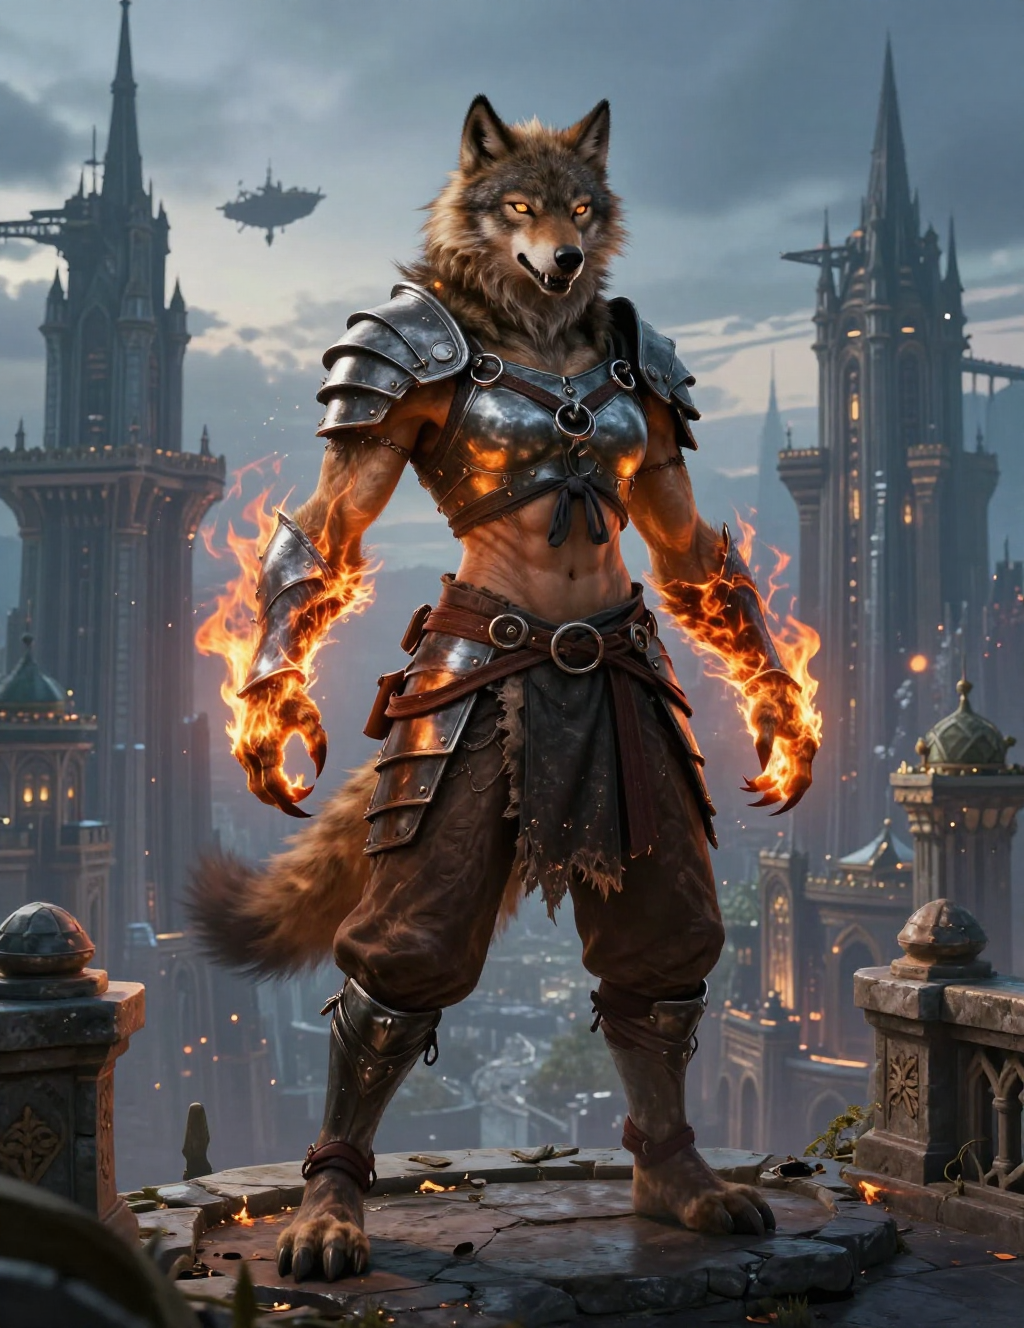

In [112]:
prompt = "A muscular werewolf-man hybrid monster, standing upright on two digitigrade hind legs like a human, humanoid torso and arms covered in dark fur, wolf-like head with pointed ears and a long snout full of fangs, clawed human-like hands, standing atop a storm-battered coastal cliff, crackling lightning splitting a churning dark sky behind it, wind whipping its fur and a torn cloak, wild seas crashing against jagged rocks below, mid-howl with head thrown back, electric blue-white light flickering along its claws, epic fantasy illustration, dramatic high-contrast lighting, dark stormy palette with bursts of lightning-white and thunderhead purple"
prompt = "A muscular werewolf-woman hybrid monster, standing upright on two digitigrade hind legs like a human, humanoid torso and arms caught mid-motion in a powerful claw strike against a large boulder, the exact moment of impact captured, a visible shockwave of cracked stone fragments and rippling blue-white thunder-light radiating outward from the point of the blow, wolf-like head snarling with the exertion of the strike, clawed hand buried into the shattering rock, electric energy crackling along its forearm, dust and debris frozen mid-explosion around the impact point, dramatic dynamic action pose, dark stormy sky with distant lightning overhead, high-contrast lighting with the thunder-light as the primary illumination, epic fantasy illustration, explosive kinetic energy"
# prompt = "A werewolf guardian in hybrid form standing sentinel at the edge of an ancient, moss-draped forest, thick roots and thorny vines coiling protectively around the trees behind it, dappled twilight sunlight filtering through a dense canopy, faint shimmering aura suggesting a fey manifest zone, fur silvered like moonlight, piercing amber eyes watching over the wilderness, epic fantasy illustration, painterly detail, muted greens and deep browns, sense of ancient stillness and quiet menace"
# prompt = "A muscular werewolf-man hybrid monster, standing upright on two digitigrade hind legs like a human, humanoid torso and arms covered in dark fur, wolf-like head with pointed ears and a long snout full of fangs, clawed human-like hands, standing sentinel at the edge of an ancient moss-draped forest, thick roots and thorny vines coiling protectively around the trees behind it, dappled twilight sunlight filtering through a dense canopy, faint shimmering aura suggesting a fey manifest zone, fur silvered like moonlight, piercing amber eyes watching over the wilderness, epic fantasy illustration, painterly detail, muted greens and deep browns, sense of ancient stillness and quiet menace"
# prompt = "A muscular werewolf-man hybrid monster, standing upright on two digitigrade hind legs like a human, humanoid torso and arms covered in pale silvery-white fur, wolf-like head with pointed ears and a long snout full of fangs, clawed human-like hands, gently laying one clawed hand upon a wounded, kneeling human warrior, soft golden-white healing light glowing from the point of contact and radiating outward, warm holy radiance surrounding both figures, faint glowing motes drifting upward like embers, serene and compassionate expression despite the beastly features, epic fantasy illustration, soft luminous lighting, warm gold and pale silver palette, sense of gentle sacred power and quiet mercy"
prompt = "A muscular werewolf-woman hybrid monster, standing upright on two digitigrade hind legs like a human, chestnut-brown fur, wolf-like head with pointed ears and a long snout full of fangs, clawed human-like hands, the outfit consists of a sleeveless tied shirt, with loose pants that are secured with long fabric belts high on the waist, typically coming up about an inch above the belly button. The pants are also tied around the calves or tucked into belted sandals or boots. Brelish armor tends to consist of many layers of enameled metal attached by rings wearing a breastplate, seamlessly follows the contours of its beastly body, standing atop a high stone balcony overlooking Sharn, the City of Towers, soaring mile-high spires of mismatched architectural styles stacking into a hazy sky, flying boats gliding between towers and skybridges in the distance, flames curling and dancing along the werewolf's clawed hands and forearms without burning the armor, embers drifting off its claws into the air, dusk lighting with cool blue-grey stone towers and a warm orange glow radiating only from the werewolf's fiery hands, epic fantasy illustration, dramatic and imposing"
# prompt = "Cover of a werewolf related D&D book, A muscular werewolf-woman hybrid monster, standing upright on two digitigrade hind legs like a human, humanoid torso covered in rich chestnut-brown fur, wolf-like head with pointed ears and a long snout full of fangs, clawed human-like hands, wearing form-fitting metal plate armor with articulated braces on the forearms and shins that seamlessly follows the contours of its beastly body, standing atop a high stone balcony overlooking Sharn, the City of Towers, soaring mile-high spires of mismatched architectural styles stacking into a hazy sky, boat-shaped skycoaches gliding between towers and skybridges in the distance, flames curling and dancing along the werewolf's clawed hands and forearms without burning the armor, embers drifting off its claws into the air, dusk lighting with cool blue-grey stone towers and a warm orange glow radiating only from the werewolf's fiery hands, epic fantasy illustration, dramatic and imposing"
# prompt = "A massive white-furred dire wolf, thick shaggy winter coat, powerfully built with a broad chest and long legs built for snow, standing atop a windswept frozen tundra, jagged ice formations and snow-drifted rocks scattered around it, a pale low sun breaking through heavy grey clouds, frost and mist clinging to the ground, breath visible in the freezing air, piercing pale blue eyes, a distant herd of wild elk or mammoth-like creatures visible far in the background, epic fantasy illustration, cold desaturated palette of white, pale blue, and grey, sense of primal kinship with the wild and untamed frontier"
# prompt = "A muscular werewolf-man hybrid monster, standing upright on two digitigrade hind legs like a human, humanoid torso and arms covered in silver-grey fur, wolf-like head with pointed ears and a long snout full of fangs, clawed human-like hands, bare-chested but draped in a fine fur-trimmed cloak and ornate heraldic sash befitting nobility, standing with a commanding, dignified posture atop a rocky outcrop overlooking a vast wilderness, ancient standing stones arranged in a precise, deliberate circle around the outcrop, tall pines and untamed forest stretching to the horizon below, cool silver and pale blue moonlight casting sharp, orderly shadows, calm and imperious expression, epic fantasy illustration, regal and composed atmosphere amid raw nature, muted silver, ivory, and deep blue palette"
# prompt = "A muscular werewolf-man hybrid monster, standing upright on two digitigrade hind legs like a human, humanoid torso and arms covered in dark grey fur with a faint purple sheen, wolf-like head with pointed ears and a long snout full of fangs, clawed human-like hands, eyes glowing pale dull white with a single thin dark slit bisecting each iris like a vertical chasm, giving them the unsettling look of a slitted, all-seeing eye, a touch of madness in the fixed, unblinking stare, an intense predatory focus as though tracking an unseen scent or sound, head tilted slightly as if listening to something no one else can hear, standing in a shadowed alley or dim moonlit ruin, faint tendrils of otherworldly violet mist curling at its feet, cool desaturated palette of charcoal, dull white, and muted violet, epic fantasy illustration, eerie and unsettling atmosphere"
# prompt = "A muscular werewolf-man hybrid monster, standing upright on two digitigrade hind legs like a human, humanoid torso and arms covered in dark grey fur with a distinct, unmistakable purple sheen rippling across it, wolf-like head with pointed ears and a long snout full of fangs, clawed human-like hands, striking eyes that glow a dull pale white, each iris split by a single thin dark vertical slit running top to bottom like a chasm, resembling a slitted, all-seeing eye, a fixed, unblinking, faintly mad stare, nostrils flared and head tilted low as if intently tracking a scent or sound only it can perceive, intense predatory focus, standing in a shadowed alley or dim moonlit ruin, plain cool charcoal and stone-grey surroundings with no unnatural mist or colored light, epic fantasy illustration, eerie and unsettling atmosphere, close attention on the face and eyes"
# prompt = "A muscular werewolf-woman hybrid monster, standing upright on two digitigrade hind legs like a human, humanoid torso and arms covered in dark fur dusted with an iridescent, faintly opalescent sheen, wolf-like head with pointed ears and a long snout full of fangs, clawed human-like hands, adorned with delicate woven vines, small wildflowers, and faintly glowing fungal motes threaded through its fur like fey regalia, standing within an otherworldly moonlit glade where the trees are too perfectly arranged and the light falls in impossible soft shafts, will-o'-the-wisp lights drifting between ancient twisted trees, a shimmering fold in the air behind it hinting at a boundary between worlds, luminous pale moonlight in silver, lavender, and soft green hues, an ancient and knowing expression, epic fantasy illustration, dreamlike and enchanted atmosphere"
# prompt = "A muscular, athletic werewolf-woman hybrid monster, standing upright on two digitigrade hind legs like a human, lean powerfully built humanoid torso and arms covered in charcoal-black fur, wolf-like head with pointed ears and a long snout full of fangs, clawed human-like hands, eyes glowing a faint cold violet in the darkness, standing watchfully at the edge of an ancient crypt or barrow-field, weathered stone tombs and cracked sarcophagi half-sunken into misty ground, tendrils of unnatural darkness curling low around her feet without touching her, a sliver of pale moonlight cutting through heavy shadow to illuminate her silhouette, tense guardian posture as if standing sentinel against something stirring nearby, dramatic near-total darkness broken only by cold violet and pale silver light, epic fantasy illustration, ominous but resolute atmosphere"
# prompt = "A muscular, athletic werewolf-woman hybrid monster, standing upright on two digitigrade hind legs like a human, lean powerfully built humanoid torso and arms covered in ash-grey fur, wolf-like head with pointed ears and a long snout full of fangs, clawed human-like hands, standing at a literal threshold — a weathered stone crossroads marker or an old ferry crossing at the edge of a misty, dead-grey wasteland reminiscent of the Mournland, one side of the scene lush and alive, the other side ashen and still, ground fog pooling low, pale directionless light with no clear sun, calm, patient, watchful expression as if guiding something unseen across the boundary, worn traveler's wrappings on her forearms and a satchel across her back, muted grey, dull green, and bone-white palette, epic fantasy illustration, quiet liminal atmosphere"
# prompt = "A muscular, athletic werewolf-woman hybrid monster, standing upright on two digitigrade hind legs like a human, lean powerfully built humanoid torso and arms covered in dark iron-grey fur, wolf-like head with pointed ears and a long snout full of fangs, clawed human-like hands, standing atop the ramparts of a weathered frontier fortress, cracked battlements and old siege damage scarring the stone around him, a wide contested borderland stretching out below with distant burned-out battlefield remnants, overcast steel-grey sky with a faint reddish tint at the horizon suggesting a far-off war, alert, disciplined sentry posture, gripping a simple worn iron banner-pole or spear planted into the stone beside him, muted iron, ash, and dull crimson palette, epic fantasy illustration, tense vigilant atmosphere of a soldier keeping an eternal watch"
# prompt = "A muscular, athletic werewolf-man hybrid monster, standing upright on two digitigrade hind legs like a human, lean powerfully built humanoid torso and arms covered in dark iron-grey fur, jagged bone quills and hardened spines bristling along its shoulders, back, and forearms like living armor, wolf-like head with pointed ears and a long snout full of fangs, clawed human-like hands, standing atop the ramparts of a weathered frontier fortress, cracked battlements and old siege damage scarring the stone around him, a wide contested borderland stretching out below with distant burned-out battlefield remnants, overcast steel-grey sky with a faint reddish tint at the horizon suggesting a far-off war, alert, disciplined sentry posture, gripping a simple worn iron banner-pole or spear planted into the stone beside him, muted iron, ash, and dull crimson palette, epic fantasy illustration, tense vigilant atmosphere of a soldier keeping an eternal watch"
# prompt = "A muscular, athletic werewolf-woman hybrid monster, standing upright on two digitigrade hind legs like a human, lean powerfully built humanoid body, skin and fur visibly hardening into cracked, granite-grey stone plating across her shoulders, forearms, and knuckles like living rock, wolf-like head with pointed ears and a long snout full of fangs, clawed human-like hands braced against a crumbling fortress gate under assault, arrows and spear-tips shattering harmlessly against her stone-plated arms as she holds the breach alone, dust and rubble falling around her, warriors in worn armor rallying behind her in the gate's shadow, stormy overcast sky lit by distant fire, muted stone-grey, ash, and ember-orange palette, epic fantasy illustration, defiant last-stand atmosphere"

# prompt = "Extreme close-up portrait of a werewolf-hybrid monster's face in near-total darkness, wolf-like snout and fangs barely visible at the edges of the frame, the only light source is its own eyes glowing with a pale, ringed glow reminiscent of a moon with a dark band across its center, faint illumination catching just the tips of its fangs and the edge of a clawed hand raised near its face, everything else swallowed in black, dust motes faintly visible drifting through the glow, epic fantasy illustration, minimalist and eerie composition, high contrast between the glowing pale eyes and the surrounding darkness"
# prompt = "The exact moment of a werewolf's transformation into Hybrid Form, a humanoid silhouette mid-shift, limbs elongating and fur erupting across charcoal-black skin, wolf-like head still partly forming, dark shadow pouring and curling off her body like liquid smoke, faint cold violet glow beginning to kindle in her half-formed eyes, standing in a dim crypt or shadowed hallway, a small group of ordinary onlookers in the foreground caught mid-recoil, frozen in the act of stumbling backward and shielding their faces in fear, dramatic near-total darkness broken only by a single flickering torch and the cold violet light from her eyes, epic fantasy illustration, tense and horror-tinged atmosphere, dynamic mid-action composition"
negative_prompt = "blurry, low detail, calm weather, indoors, cute, cartoonish"
# negative_prompt = "blurry, low detail, calm weather, indoors, cute, cartoonish, quadruped, four legs, regular wolf, dog, animal on all fours, blurry, extra limbs"
negative_prompt = "blurry, low detail, calm weather, indoors, cute, cartoonish, quadruped, four legs, regular wolf, dog, animal on all fours, blurry, extra limbs, wilderness, forest, torn or ill-fitting armor, white or grey fur, balloons, hot air balloon, burning buildings, city on fire, exaggerated or sexualized anatomy"
# negative_prompt = "blurry, low detail, calm weather, indoors, cute, cartoonish, quadruped, four legs, regular wolf, dog, animal on all fours, blurry, extra limbs, armor, plate armor, weapons, buildings, architecture, chaotic composition, ragged clothing, disorder, chestnut or white fur"
# negative_prompt = "blurry, low detail, calm weather, indoors, cute, cartoonish, quadruped, four legs, regular wolf, dog, animal on all fours, blurry, extra limbs, purple vapours in the background"
# negative_prompt = "blurry, low detail, calm weather, indoors, cute, cartoonish, quadruped, four legs, regular wolf, dog, animal on all fours, blurry, extra limbs, armor, weapons, warm colors, calm expression, symmetrical eyes without slit, purple mist, purple lighting, purple background, glowing purple effects"
# negative_prompt = "blurry, low detail, calm weather, indoors, cute, cartoonish, quadruped, four legs, regular wolf, dog, animal on all fours, blurry, extra limbs, heavy armor, settled or resting pose, indoor setting, night sky, dark palette"
# negative_prompt = "blurry, low detail, calm weather, indoors, cute, cartoonish, quadruped, four legs, regular wolf, dog, animal on all fours, blurry, extra limbs, armor, modern clothing, mundane forest, harsh daylight, industrial background, vines, flowers, plant decorations, exaggerated or sexualized anatomy, vines on her body"
negative_prompt = "blurry, low detail, calm weather, indoors, cute, cartoonish, cross, quadruped, four legs, regular wolf, dog, animal on all fours, blurry, extra limbs, armor, exaggerated or sexualized anatomy, bright cheerful lighting, skeletons, zombies visible, vibrant saturated colors, cross shaped tomstones, christian tombstonea"
negative_prompt = "blurry, low detail, calm weather, indoors, cute, cartoonish, cross, quadruped, four legs, regular wolf, dog, animal on all fours, blurry, extra limbs, armor, exaggerated or sexualized anatomy, bright cheerful lighting, small soldiers"
image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=8,
    guidance_scale=0.0,
    width=1024,
    # height=1024,
    height=1328,
    # generator=torch.Generator("cuda").manual_seed(42),
).images[0]
image

In [113]:
stamp = datetime.now().strftime('%Y-%m-%dT%H%M%S')
path = f"{folder}/eyre-AI-{stamp}.png"
image.save(path)